In [1]:
import multiprocessing  # the module we will be using for multiprocessing
import numpy as np
import pandas as pd
import time
from itertools import repeat
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("white")

#Here we import our own module, which implements the function work that will be executed in
#each one of the parallel threads
import myfunctions as my


#This function is now defined in the myfunctions module
# def work(task):
#    """
#    Some amount of work that will take time
#    
#    Parameters
#    ----------
#    task : tuple
#        Contains number, loop, and number processors
#    """
#    number, loop = task
#    b = 2. * number - 1.
#    for i in range(loop):
#        a, b = b * i, number * i + b
#    return a, b

In [3]:
def plot(multip_stats):
    """
    Plots the execution times from multiprocessing runs
    
    Parameters
    ----------
    multip_stats : dictionary
        dictionary containing the execution times
    """
    serial_time = multip_stats[1].mean()
    keys = sorted(multip_stats.keys())
    keys = np.array(keys)
    speedup = []
    efficiency = []
    for number_processes in keys:
        speedup.append(serial_time / multip_stats[number_processes].mean())
        efficiency.append(speedup[-1] / number_processes)
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(211)
    plt.plot(keys, keys)
    plt.bar(keys-0.5, speedup, width=1)
    plt.ylabel('Speedup')
    ax.set_xticks(range(1, keys[-1] + 1))
    ax.set_xticklabels([])
    plt.xlim(0.5, keys[-1] + .5)
    
    ax = fig.add_subplot(212)
    plt.bar(keys-0.5, efficiency, width=1)
    plt.ylabel('Efficiency')
    plt.xlabel('Number of processes')
    ax.set_xticks(range(1, keys[-1] + 1))
    ax.set_xticklabels(range(1, keys[-1] + 1))
    plt.xlim(0.5, keys[-1] + .5)
    print("Saving speedup graph")
    plt.savefig("./parallel_speedup_efficiency.png")

There are 40 CPUs on this machine
1.2.3.4.5.6.7.8.9.10.11.12.13.14.15.16.17.18.19.20.21.22.23.24.25.26.27.28.29.30.31.32.33.34.35.36.37.38.39.40.41.42.43.44.45.46.47.48.49.50.51.52.53.54.55.56.57.58.59.60.61.62.63.64.65.66.67.68.69.70.71.72.73.74.75.76.77.78.79.80.Total time: 195.6793396472931 secs
Saving speedup graph


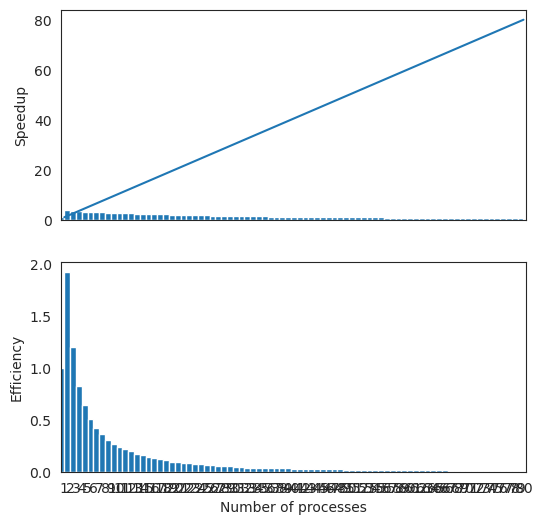

In [4]:
cpu_count = multiprocessing.cpu_count()
print("There are %d CPUs on this machine" % cpu_count)
number_processes = range(1, cpu_count * 2 + 1)
loop = 10
total_tasks = 10
tasks = np.float64(range(1, total_tasks))
number_of_times_to_repeat = 10
multip_stats = {}
total_time=time.time()
for number in number_processes:
    print(f"{number}.",end='')
    multip_stats[number] = np.empty(number_of_times_to_repeat)
    for i in range(number_of_times_to_repeat):
        pool = multiprocessing.Pool(number)
        start_time = time.time()
        results = pool.map_async(my.work, zip(tasks, repeat(loop)))
        pool.close()
        pool.join()
        end_time = time.time()
        multip_stats[number][i] = end_time - start_time
total_end_time=time.time()
print("\nTotal time: {} secs".format(total_end_time-total_time))
plot(multip_stats)